# Example-13: TbT data normalization

In [1]:
# Import

import epics
import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import pv_make
from harmonica.window import Window
from harmonica.data import Data

import matplotlib.pyplot as plt
from time import sleep

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(1024, 'cosine_window', 5.0)
Data(1, Window(1024, 'cosine_window', 5.0))
tensor([0.], dtype=torch.float64)
tensor(1.000000000000e+00, dtype=torch.float64)


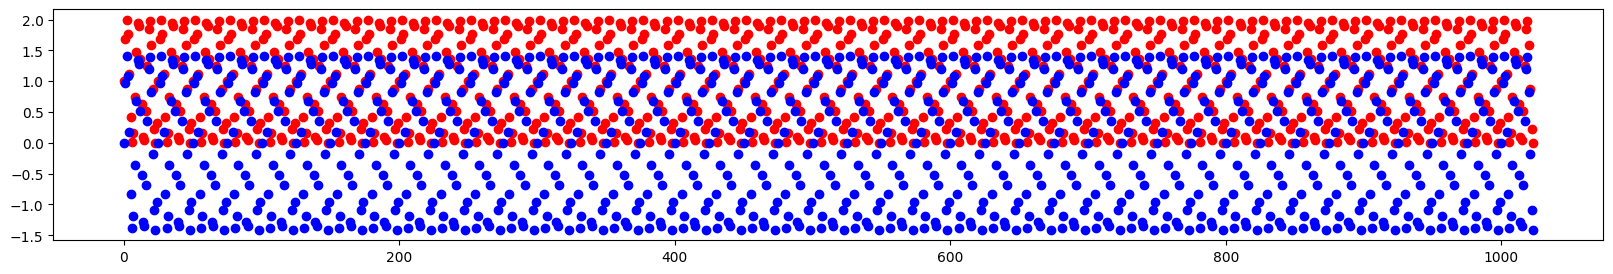

In [3]:
# Set window

w = Window.from_cosine(1024, 5.0, dtype=dtype, device=device)
print(w)

# Set TbT

d = Data.from_data(w, torch.stack([1.0 + torch.sin(2.0*numpy.pi*0.12*torch.linspace(0, 1024-1, 1024, dtype=dtype, device=device))]))
print(d)

# Normalize (change work)
# If window flag is True, window weighted mean is subtracted

d.normalize(window=True)
print(*torch.round(d.window_mean()))
print(torch.std(d.work))

# Plot 

t = torch.linspace(0, w.length-1, w.length, dtype=dtype, device=device)
plt.figure(figsize=(20, 3))
plt.scatter(t.cpu().numpy(), d.data[0].cpu().numpy(), color='red')
plt.scatter(t.cpu().numpy(), d.work[0].cpu().numpy(), color='blue')
plt.show()

# Reset data

d.reset()

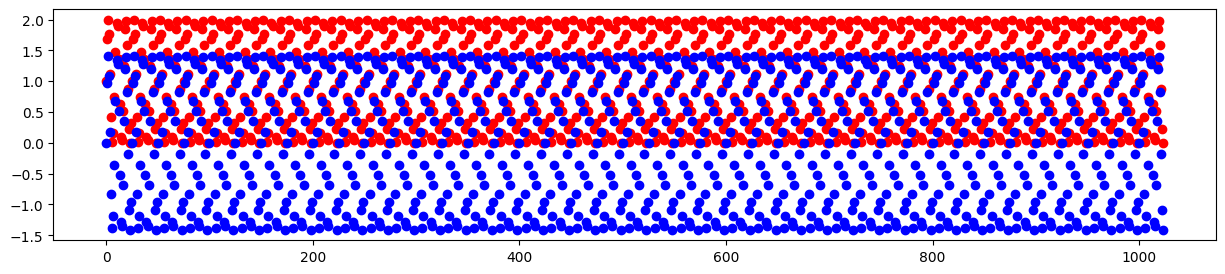

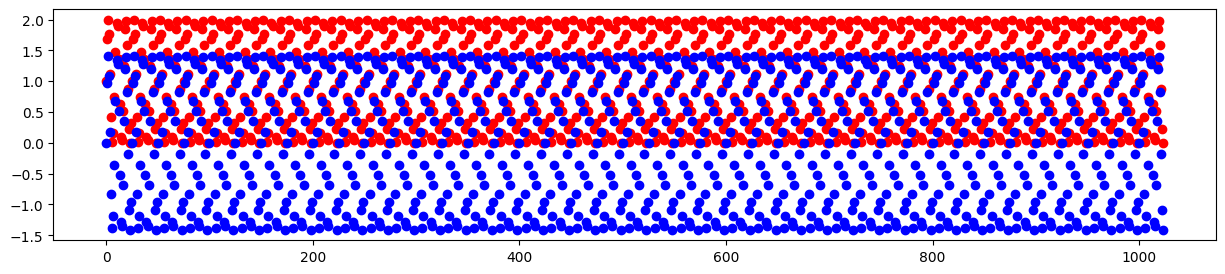

In [4]:
# Alternative normalization

from harmonica.statistics import weighted_mean, variance
from harmonica.statistics import standardize

d.work -= weighted_mean(d.work, w.window)
d.work /= variance(d.work).sqrt()

plt.figure(figsize=(15, 3))
plt.scatter(t.cpu().numpy(), d.data[0].cpu().numpy(), color='red')
plt.scatter(t.cpu().numpy(), d.work[0].cpu().numpy(), color='blue')
plt.show()
d.reset()

d.work = standardize(d.work, center_estimator=lambda data: weighted_mean(data, weight=w.window), spread_estimator=variance).reshape_as(d.data)
plt.figure(figsize=(15, 3))
plt.scatter(t.cpu().numpy(), d.data[0].cpu().numpy(), color='red')
plt.scatter(t.cpu().numpy(), d.work[0].cpu().numpy(), color='blue')
plt.show()
d.reset()

In [5]:
# Clean

del w
del d
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()